# Computational Statistical Mechanics - pamuduamarasinghe

# 1. Harmonic wave functions

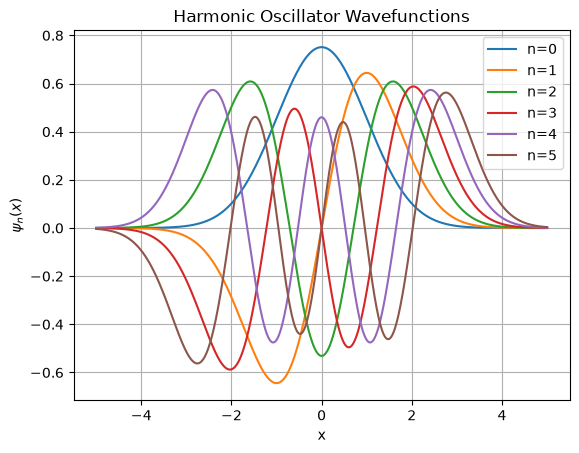

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite , factorial

#Harmonoic oscillator wavefunction
def Psi(n,x,x0=1.0):
    Hn = hermite(n)
    norm = 1.0 / np.sqrt(np.sqrt(np.pi)*(2**n)*factorial(n)*x0)
    return norm * Hn(x/x0)*np.exp(-x**2/(2*x0**2))

x = np.linspace(-5, 5, 1000)

#n until 5
for n in range(6):
    plt.plot(x,Psi(n,x),label=f'n={n}')
plt.title('Harmonic Oscillator Wavefunctions')
plt.xlabel('x')
plt.ylabel(r'$\psi_n(x)$')
plt.legend()
plt.grid()
plt.show()    

# 2. Harmonic density matrix

Partition Function (Z) = 0.9595173756674712


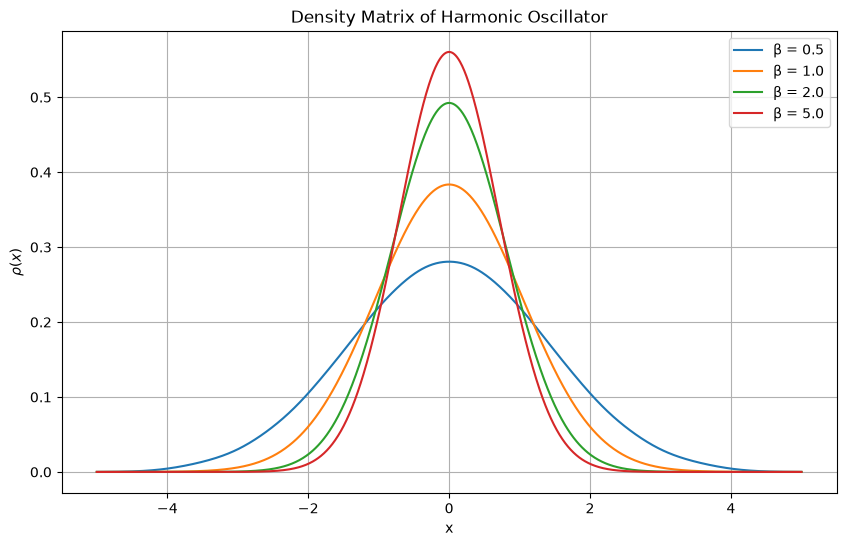

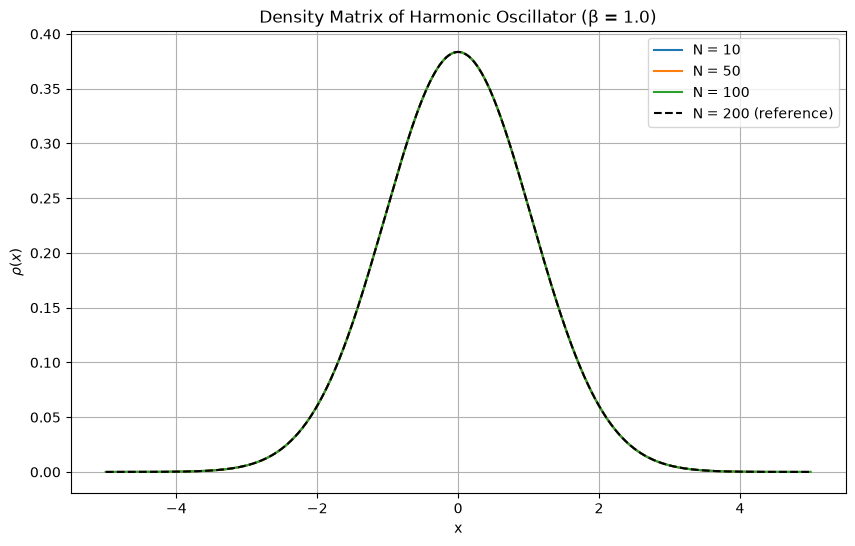

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, factorial


#Harmonoic oscillator wavefunction
def Psi(n,x,x0=1.0):
    Hn = hermite(n)
    norm = 1.0 / np.sqrt(np.sqrt(np.pi)*(2**n)*factorial(n)*x0)
    return norm * Hn(x/x0)*np.exp(-x**2/(2*x0**2))


# Constants
hbar = 1.0
m = 1.0
omega = 1.0

x0 = np.sqrt(hbar/(m*omega))


# Energy
def Energy(n):

    return hbar * omega * (n + 0.5)


# Partition function
def Z(beta, nmax):

    return sum(np.exp(-beta * Energy(i)) for i in range(nmax))


# Probability
def P(n, beta, nmax):

    return np.exp(-beta * Energy(n)) / Z(beta, nmax)


#density matrix
def density_matrix(nmax, x, beta):

    rho = np.zeros_like(x)

    for i in range(nmax):

        weight = np.exp(-beta * Energy(i))

        if weight < 1e-12:
            break

        rho += (weight / Z(beta, nmax)) * Psi(i, x, x0)**2

    return rho


x = np.linspace(-5, 5, 1000)
betas = [0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(10,6))

for beta in betas:
    rho = density_matrix(10, x, beta)
    plt.plot(x, rho, label=f"β = {beta}")

plt.title("Density Matrix of Harmonic Oscillator")
plt.xlabel("x")
plt.ylabel(r"$\rho(x)$")
plt.grid(True)
plt.legend()



beta = 1.0
N = 100
Z_value = Z(beta, N)

print("Partition Function (Z) =", Z_value)

# density matrix for different N values
N_values = [10, 50, 100]

plt.figure(figsize=(10,6))

for N in N_values:

    rho = density_matrix(N, x, beta)
    plt.plot(x, rho, label=f"N = {N}")

plt.plot(x, density_matrix(1000, x, beta), 'k--', label='N = 200 (reference)')
plt.title(f"Density Matrix of Harmonic Oscillator (β = {beta})")
plt.xlabel("x")
plt.ylabel(r"$\rho(x)$")
plt.grid(True)
plt.legend()

plt.show()